# M5 Forecasting — Accuracy Dataset Audit

**Phase 0E — empirical feasibility audit only.** M5 contains Walmart retail unit sales, not e-commerce transactions. This notebook creates no forecasting model, lag/rolling feature, anomaly score, or inventory rule. The wide sales matrices remain wide to avoid an unnecessary ~59M-row long representation.

In [1]:
from pathlib import Path
import gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option('display.max_columns',100)
RAW=Path('../data/raw/m5'); FILES=sorted(RAW.glob('*.csv'))
expected=['calendar.csv','sales_train_evaluation.csv','sales_train_validation.csv','sample_submission.csv','sell_prices.csv']
assert [p.name for p in FILES]==expected
[(p.name,p.stat().st_size/1024**2) for p in FILES]

[('calendar.csv', 0.09867572784423828),
 ('sales_train_evaluation.csv', 116.09699058532715),
 ('sales_train_validation.csv', 114.44828605651855),
 ('sample_submission.csv', 4.98655891418457),
 ('sell_prices.csv', 193.9733362197876)]

## 1. Dataset identity and file audit
M5 was designed to forecast hierarchical Walmart item sales over two 28-day competition horizons. Candidate keys, missingness, and memory are checked independently. Integer sales are loaded as `int16` and identifiers as categories for a realistic local workflow; this changes representation, not values.

In [2]:
def sales_dtype(path):
    cols=pd.read_csv(path,nrows=0).columns; return {**{c:'category' for c in ['id','item_id','dept_id','cat_id','store_id','state_id']},**{c:'int16' for c in cols if c.startswith('d_')}}
loaders={
 'calendar.csv':lambda p:pd.read_csv(p,parse_dates=['date'],dtype={'wm_yr_wk':'int32','weekday':'category','wday':'int8','month':'int8','year':'int16','d':'category','event_name_1':'category','event_type_1':'category','event_name_2':'category','event_type_2':'category','snap_CA':'int8','snap_TX':'int8','snap_WI':'int8'}),
 'sales_train_evaluation.csv':lambda p:pd.read_csv(p,dtype=sales_dtype(p)), 'sales_train_validation.csv':lambda p:pd.read_csv(p,dtype=sales_dtype(p)),
 'sample_submission.csv':lambda p:pd.read_csv(p,dtype={'id':'category',**{f'F{i}':'int16' for i in range(1,29)}}),
 'sell_prices.csv':lambda p:pd.read_csv(p,dtype={'store_id':'category','item_id':'category','wm_yr_wk':'int32','sell_price':'float32'})}
keys={'calendar.csv':['d'],'sales_train_evaluation.csv':['id'],'sales_train_validation.csv':['id'],'sample_submission.csv':['id'],'sell_prices.csv':['store_id','item_id','wm_yr_wk']}
summaries=[]; missing_summaries={}
for p in FILES:
    t=time.perf_counter(); df=loaders[p.name](p); key=keys[p.name]
    summaries.append({'file':p.name,'rows':len(df),'columns':df.shape[1],'disk_mb':p.stat().st_size/1024**2,'memory_mb':df.memory_usage(deep=True).sum()/1024**2,'duplicate_rows':int(df.duplicated().sum()),'candidate_key':' + '.join(key),'key_duplicate_rows':int(df.duplicated(key,keep=False).sum()),'load_seconds':time.perf_counter()-t})
    miss=df.isna().sum(); missing_summaries[p.name]=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing_n':miss,'missing_pct':miss/len(df)*100}).query('missing_n > 0')
    del df; gc.collect()
display(pd.DataFrame(summaries).round(3))
for name,x in missing_summaries.items(): print('\n',name,'missing columns:',len(x)); display(x.head(20).round(3))
display(pd.DataFrame([['calendar','one calendar day','d; date also unique'],['sell_prices','one item-store-week observed price','store_id + item_id + wm_yr_wk'],['sales matrices','one item-store series with daily values','id'],['sample_submission','one series-horizon identifier with 28 forecast slots','id']],columns=['table','grain','candidate_key']))

,file,rows,columns,disk_mb,memory_mb,duplicate_rows,candidate_key,key_duplicate_rows,load_seconds
0,calendar.csv,1969,14,0.099,0.218,0,d,0,0.022
1,sales_train_evaluation.csv,30490,1947,116.097,116.625,0,id,0,3.421
2,sales_train_validation.csv,30490,1919,114.448,114.996,0,id,0,3.353
3,sample_submission.csv,60980,29,4.987,10.026,0,id,0,0.209
4,sell_prices.csv,6841121,4,193.973,72.010,0,store_id + item_id + wm_yr_wk,0,2.983



 calendar.csv missing columns: 4


,dtype,missing_n,missing_pct
event_name_1,category,1807,91.772
event_type_1,category,1807,91.772
event_name_2,category,1964,99.746
event_type_2,category,1964,99.746



 sales_train_evaluation.csv missing columns: 0


,dtype,missing_n,missing_pct


...


 sample_submission.csv missing columns: 0


,dtype,missing_n,missing_pct



 sell_prices.csv missing columns: 0


,dtype,missing_n,missing_pct


,table,grain,candidate_key
0,calendar,one calendar day,d; date also unique
1,sell_prices,one item-store-week observed price,store_id + item_id + wm_yr_wk
2,sales matrices,one item-store series with daily values,id
3,sample_submission,one series-horizon identifier with 28 forecast...,id


## 2. Hierarchy and temporal coverage
The evaluation matrix is the audit base because it includes 28 days beyond validation. The two matrices are checked for identical hierarchy and identical first 1,913 values despite their horizon-specific ID suffixes.

In [3]:
evaluation=loaders['sales_train_evaluation.csv'](RAW/'sales_train_evaluation.csv'); validation=loaders['sales_train_validation.csv'](RAW/'sales_train_validation.csv'); calendar=loaders['calendar.csv'](RAW/'calendar.csv')
id_cols=['item_id','dept_id','cat_id','store_id','state_id']; eval_days=[c for c in evaluation if c.startswith('d_')]; val_days=[c for c in validation if c.startswith('d_')]
hierarchy=pd.Series({'states':evaluation.state_id.nunique(),'stores':evaluation.store_id.nunique(),'categories':evaluation.cat_id.nunique(),'departments':evaluation.dept_id.nunique(),'items':evaluation.item_id.nunique(),'item-store series':len(evaluation),'unique item-store pairs':evaluation[['item_id','store_id']].drop_duplicates().shape[0]}); display(hierarchy.to_frame('count'))
checks=pd.Series({'validation days':len(val_days),'evaluation days':len(eval_days),'extra evaluation days':len(eval_days)-len(val_days),'hierarchy rows equal':evaluation[id_cols].astype(str).reset_index(drop=True).equals(validation[id_cols].astype(str).reset_index(drop=True)),'first 1913 sales values equal':np.array_equal(evaluation[val_days].to_numpy(),validation[val_days].to_numpy())}); display(checks.to_frame('value'))
day_map=calendar.set_index('d').date; temporal=pd.Series({'first sales day':eval_days[0],'first sales date':day_map[eval_days[0]],'last validation day':val_days[-1],'last validation date':day_map[val_days[-1]],'last evaluation training day':eval_days[-1],'last evaluation training date':day_map[eval_days[-1]],'calendar final day':str(calendar.d.iloc[-1]),'calendar final date':calendar.date.iloc[-1],'calendar days beyond evaluation training':len(calendar)-len(eval_days),'known competition horizon days':28}); display(temporal.to_frame('value'))
del validation; gc.collect()

,count
states,3
stores,10
categories,3
departments,7
items,3049
item-store series,30490
unique item-store pairs,30490


,value
validation days,1913
evaluation days,1941
extra evaluation days,28
hierarchy rows equal,True
first 1913 sales values equal,True


,value
first sales day,d_1
first sales date,2011-01-29 00:00:00
last validation day,d_1913
last validation date,2016-04-24 00:00:00
last evaluation training day,d_1941
last evaluation training date,2016-05-22 00:00:00
calendar final day,d_1969
calendar final date,2016-06-19 00:00:00
calendar days beyond evaluation training,28
known competition horizon days,28


0

## 3. Sales density across hierarchy levels
Active days are days with units > 0. ‘Extreme intermittency’ is a descriptive flag for ≥90% zero days, not a modeling filter. Sparse/moderate/dense bands below are audit summaries only: ≥75%, 25–<75%, and <25% zero days.

In [4]:
sales=evaluation[eval_days].to_numpy(dtype=np.int32); n_days=sales.shape[1]
def aggregate_by(cols):
    codes,_=pd.factorize(pd.MultiIndex.from_frame(evaluation[cols]),sort=True); out=np.zeros((codes.max()+1,n_days),dtype=np.int64); np.add.at(out,codes,sales); return out
levels={'item-store':sales,'department-store':aggregate_by(['dept_id','store_id']),'category-store':aggregate_by(['cat_id','store_id']),'store-total':aggregate_by(['store_id']),'category-total':aggregate_by(['cat_id'])}
density=[]
for level,a in levels.items():
    active=(a>0).sum(1); zero_pct=(a==0).mean(1)*100; total=a.sum(1)
    density.append({'level':level,'series':len(a),'median_active_days':np.median(active),'median_active_ratio_pct':np.median(active/n_days*100),'overall_zero_day_pct':(a==0).mean()*100,'series_extreme_>=90%_zero_pct':(zero_pct>=90).mean()*100,'series_sparse_>=75%_zero_pct':(zero_pct>=75).mean()*100,'series_moderate_25-<75%_zero_pct':((zero_pct>=25)&(zero_pct<75)).mean()*100,'series_dense_<25%_zero_pct':(zero_pct<25).mean()*100,'median_total_units':np.median(total)})
display(pd.DataFrame(density).set_index('level').round(3))

,series,median_active_days,median_active_ratio_pct,overall_zero_day_pct,series_extreme_>=90%_zero_pct,series_sparse_>=75%_zero_pct,series_moderate_25-<75%_zero_pct,series_dense_<25%_zero_pct,median_total_units
level,,,,,,,,,
item-store,30490,518.0,26.687,67.998,16.835,47.235,47.609,5.156,868.0
department-store,70,1936.0,99.742,0.267,0.000,0.000,0.000,100.000,572785.0
category-store,30,1936.0,99.742,0.215,0.000,0.000,0.000,100.000,1431960.5
store-total,10,1938.5,99.871,0.124,0.000,0.000,0.000,100.000,6374248.5
category-total,3,1937.0,99.794,0.155,0.000,0.000,0.000,100.000,14764090.0


## 4. Bottom-level history quality and intermittency
First sale, active lifespan, active days, totals, and longest zero run describe series history. All-zero series are kept and reported. Descriptive sparsity bands are not selection rules.

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
first_nonzero_day_index,30490.0,407.194490,477.176658,1.000000,1.000000,2.000000,160.000000,767.000000,1162.000000,1325.000000,1580.000000,1846.000000
active_lifespan_days,30490.0,1530.677402,477.600723,48.000000,773.000000,1172.000000,1773.000000,1938.000000,1941.000000,1941.000000,1941.000000,1941.000000
total_units,30490.0,2195.053231,5290.421671,15.000000,175.000000,366.000000,868.000000,2072.000000,4763.200000,8143.550000,21357.880000,253859.000000
active_days,30490.0,621.163365,433.631478,12.000000,139.000000,262.000000,518.000000,903.000000,1274.000000,1462.000000,1771.110000,1938.000000
active_ratio_pct,30490.0,32.002234,22.340622,0.618238,7.161257,13.498197,26.687275,46.522411,65.636270,75.321999,91.247295,99.845440
zero_pct,30490.0,67.997766,22.340622,0.154560,34.363730,53.477589,73.312725,86.501803,92.838743,95.002576,97.372488,99.381762
longest_zero_run,30490.0,477.172581,438.454078,1.000000,43.000000,101.000000,351.000000,782.000000,1169.000000,1329.000000,1579.000000,1845.000000


,series
all-zero series,0
extreme >=90% zero,5133
sparse >=75% zero,14402
moderate 25-<75% zero,14516
dense <25% zero,1572


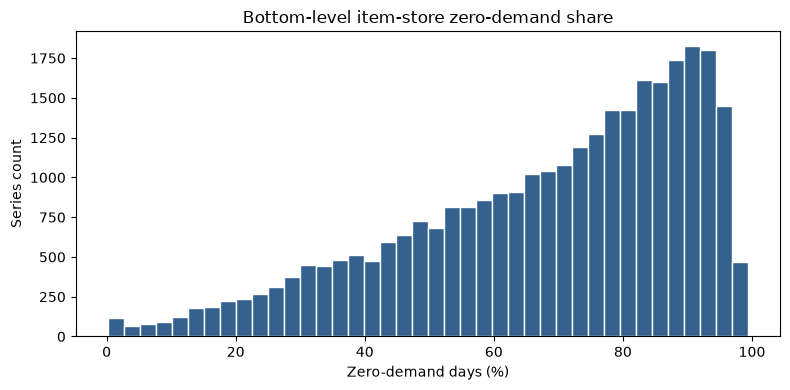

Interpretation: intermittency is structural and must remain visible in grain and metric decisions.


In [5]:
nonzero=sales>0; has_sales=nonzero.any(1); first=np.where(has_sales,nonzero.argmax(1),-1); last=np.where(has_sales,n_days-1-nonzero[:,::-1].argmax(1),-1); active=nonzero.sum(1); lifespan=np.where(has_sales,last-first+1,0); totals=sales.sum(1); zero_pct=(~nonzero).mean(1)*100
def longest_zero_run(row):
    z=np.r_[False,row==0,False]; d=np.diff(z.astype(np.int8)); starts=np.flatnonzero(d==1); ends=np.flatnonzero(d==-1); return int((ends-starts).max(initial=0))
longest=np.fromiter((longest_zero_run(r) for r in sales),dtype=np.int16,count=len(sales))
quality=pd.DataFrame({'first_nonzero_day_index':first+1,'active_lifespan_days':lifespan,'total_units':totals,'active_days':active,'active_ratio_pct':active/n_days*100,'zero_pct':zero_pct,'longest_zero_run':longest})
display(quality.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).T)
display(pd.Series({'all-zero series':(~has_sales).sum(),'extreme >=90% zero':(zero_pct>=90).sum(),'sparse >=75% zero':(zero_pct>=75).sum(),'moderate 25-<75% zero':((zero_pct>=25)&(zero_pct<75)).sum(),'dense <25% zero':(zero_pct<25).sum()}).to_frame('series'))
fig,ax=plt.subplots(figsize=(8,4)); ax.hist(zero_pct,bins=40,color='#35618f',edgecolor='white'); ax.set(title='Bottom-level item-store zero-demand share',xlabel='Zero-demand days (%)',ylabel='Series count'); plt.tight_layout(); plt.show(); print('Interpretation: intermittency is structural and must remain visible in grain and metric decisions.')

## 5. Descriptive seasonality and event context
Aggregate daily units are compared by calendar groups without creating model features or attributing causal effects. Event/SNAP means are confounded by timing and assortment and are descriptive only.

,mean,median,sum
weekday,,,
Friday,34357.472924,34864.0,9517020
Monday,32994.931408,33451.0,9139596
Saturday,41706.269784,42488.0,11594343
Sunday,41304.050360,42647.5,11482526
Thursday,30321.039711,30757.0,8398928
Tuesday,30500.483755,30901.0,8448634
Wednesday,30130.418773,31018.0,8346126


mean      sum
year month                       
2011 1      29387.666667    88163
     2      25941.964286   726375
     3      24631.193548   763567
     4      24590.433333   737713
     5      23211.677419   719562
...                  ...      ...
2016 1      39202.774194  1215286
     2      41825.068966  1212927
     3      41153.096774  1275746
     4      42782.333333  1283470
     5      45226.454545   994982

[65 rows x 2 columns]

,days,mean_total_units
no named event,1783,34609.336511
named event,158,33029.911392


,state,mean units SNAP day,mean units non-SNAP day,SNAP days
0,CA,15823.423437,14657.744812,640
1,TX,10643.512500,9543.856264,640
2,WI,10832.662500,8892.503459,640


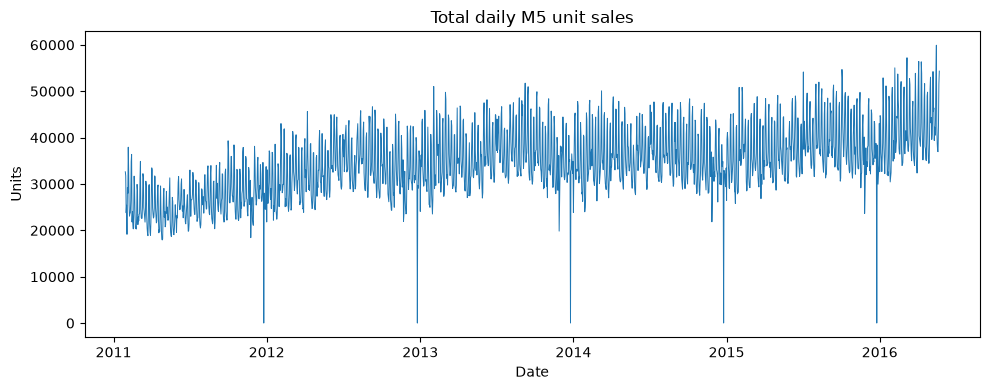

Interpretation: weekday, long-term, and calendar-linked variation exists, but this audit makes no causal event or SNAP claim.


In [6]:
total_daily=sales.sum(0); cal=calendar.iloc[:n_days].copy(); cal['total_units']=total_daily
display(cal.groupby('weekday',observed=True).total_units.agg(['mean','median','sum']).sort_index())
display(cal.groupby(['year','month']).total_units.agg(['mean','sum']))
event_compare=pd.DataFrame({'days':cal.groupby(cal.event_name_1.notna()).size(),'mean_total_units':cal.groupby(cal.event_name_1.notna()).total_units.mean()}); event_compare.index=['no named event','named event']; display(event_compare)
snap=[]
for state in ['CA','TX','WI']:
    state_daily=sales[evaluation.state_id.astype(str).eq(state).to_numpy()].sum(0); flag=cal[f'snap_{state}'].astype(bool).to_numpy(); snap.append({'state':state,'mean units SNAP day':state_daily[flag].mean(),'mean units non-SNAP day':state_daily[~flag].mean(),'SNAP days':flag.sum()})
display(pd.DataFrame(snap))
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(cal.date,total_daily,linewidth=.7); ax.set(title='Total daily M5 unit sales',xlabel='Date',ylabel='Units'); plt.tight_layout(); plt.show(); print('Interpretation: weekday, long-term, and calendar-linked variation exists, but this audit makes no causal event or SNAP claim.')

## 6. Price data audit
Prices are observed at item-store-Walmart-week grain. Full-panel coverage is descriptive because items need not be carried for every week. A price change compares adjacent observed records for a pair and is not a causal demand effect.

In [7]:
prices=loaders['sell_prices.csv'](RAW/'sell_prices.csv'); price_pairs=prices[['store_id','item_id']].drop_duplicates(); price_sorted=prices.sort_values(['store_id','item_id','wm_yr_wk']); changed=price_sorted.groupby(['store_id','item_id'],observed=True).sell_price.diff().ne(0)&price_sorted.groupby(['store_id','item_id'],observed=True).cumcount().gt(0); changes=changed.groupby([price_sorted.store_id,price_sorted.item_id],observed=True).sum(); weeks_per_pair=prices.groupby(['store_id','item_id'],observed=True).wm_yr_wk.nunique(); calendar_weeks=calendar.wm_yr_wk.nunique()
price_merge=evaluation[['store_id','item_id']].drop_duplicates().merge(price_pairs,on=['store_id','item_id'],how='left',indicator=True)
price_audit=pd.Series({'rows':len(prices),'unique item-store pairs':len(price_pairs),'sales pairs without any price':price_merge['_merge'].eq('left_only').sum(),'unique calendar weeks':calendar_weeks,'price weeks':prices.wm_yr_wk.nunique(),'full-panel row coverage pct':len(prices)/(len(price_pairs)*calendar_weeks)*100,'missing sell_price':prices.sell_price.isna().sum(),'median observed weeks/pair':weeks_per_pair.median(),'median price changes/pair':changes.median(),'pairs with >=1 price change pct':changes.gt(0).mean()*100,'maximum price changes':changes.max()}); display(price_audit.to_frame('value'))

,value
rows,6.841121e+06
unique item-store pairs,3.049000e+04
sales pairs without any price,0.000000e+00
unique calendar weeks,2.820000e+02
price weeks,2.820000e+02
full-panel row coverage pct,7.956476e+01
missing sell_price,0.000000e+00
median observed weeks/pair,2.600000e+02
median price changes/pair,2.000000e+00
pairs with >=1 price change pct,7.295179e+01


## 7. Calendar and safe covariate availability
Calendar attributes and published events/SNAP schedules exist through the 28 days beyond evaluation training and are known-in-advance candidates if the deployment context supplies them. Historical sales transformations—lags, rolling statistics, learned encodings—would require cutoff-safe computation and are not created here.

In [8]:
calendar_audit=pd.Series({'rows':len(calendar),'date unique':calendar.date.is_unique,'d unique':calendar.d.astype(str).is_unique,'weeks':calendar.wm_yr_wk.nunique(),'date min':calendar.date.min(),'date max':calendar.date.max(),'event_name_1 populated pct':calendar.event_name_1.notna().mean()*100,'event_name_2 populated pct':calendar.event_name_2.notna().mean()*100,'years':calendar.year.nunique(),'forecast-horizon rows after d_1941':len(calendar)-1941}); display(calendar_audit.to_frame('value'))
display(pd.DataFrame([['Known in advance / externally scheduled','date, weekday/wday, month, year, named events/types, SNAP schedule, wm_yr_wk','Safe only when the real future schedule is available at forecast issuance.'],['Observed/partially known','sell_price','Future price must be supplied/planned; otherwise scenario, last-known, or restricted-history treatment is needed.'],['Requires historical sales','lags, rolling values, expanding statistics','Must be computed only from sales available before each cutoff; not created in Phase 0.']],columns=['covariate class','fields/examples','horizon rule']))

,value
rows,1969
date unique,True
d unique,True
weeks,282
date min,2011-01-29 00:00:00
date max,2016-06-19 00:00:00
event_name_1 populated pct,8.227527
event_name_2 populated pct,0.253936
years,6
forecast-horizon rows after d_1941,28


,covariate class,fields/examples,horizon rule
0,Known in advance / externally scheduled,"date, weekday/wday, month, year, named events/...",Safe only when the real future schedule is ava...
1,Observed/partially known,sell_price,Future price must be supplied/planned; otherwi...
2,Requires historical sales,"lags, rolling values, expanding statistics",Must be computed only from sales available bef...


## 8. Forecasting grain options and backtesting feasibility
Options are compared, not frozen. Counts below show non-overlapping 28-day windows available before a proposed untouched final 28-day lockbox (`d_1914`–`d_1941`) under descriptive minimum-history assumptions.

In [9]:
grain_options=pd.DataFrame([['All item-store',30490,'Highest hierarchy fidelity and intermittency learning','Highest training/backtest/deployment cost; median series is sparse','Potentially crowded dashboard'],['Selected item-store','subset TBD','Focused bottom-level demonstration and manageable deployment','Selection bias and eligibility rule must be justified','Clear item examples'],['Department-store',70,'Dense, stable operational forecasting','Less granular and less challenging','Highly interpretable'],['Category-store',30,'Very dense, lightweight, easy hierarchy story','May hide item-level stock/demand dynamics','Highly interpretable'],['Multi-level demonstration','mixed','Shows reconciliation/hierarchy tradeoffs','More evaluation and explanation complexity','Strong portfolio value if scoped']],columns=['option','series','methodological value','cost/sparsity tradeoff','dashboard/deployment']); display(grain_options)
lockbox_start=1914; history_available=lockbox_start-1; bt=[]
for minimum in [365,730,1095]: bt.append({'minimum_history_days':minimum,'nonoverlapping_28d_windows_before_lockbox':max(0,(history_available-minimum)//28),'candidate recent origins (last 5)':list(range(history_available-28*5+1,history_available+1,28))})
display(pd.DataFrame(bt)); print('Proposed structure for later decision: multiple pre-lockbox rolling/expanding 28-day windows for development; retain d_1914–d_1941 untouched for one final evaluation. The competition d_1942–d_1969 labels are not in the sales files.')

,option,series,methodological value,cost/sparsity tradeoff,dashboard/deployment
0,All item-store,30490,Highest hierarchy fidelity and intermittency l...,Highest training/backtest/deployment cost; med...,Potentially crowded dashboard
1,Selected item-store,subset TBD,Focused bottom-level demonstration and managea...,Selection bias and eligibility rule must be ju...,Clear item examples
2,Department-store,70,"Dense, stable operational forecasting",Less granular and less challenging,Highly interpretable
3,Category-store,30,"Very dense, lightweight, easy hierarchy story",May hide item-level stock/demand dynamics,Highly interpretable
4,Multi-level demonstration,mixed,Shows reconciliation/hierarchy tradeoffs,More evaluation and explanation complexity,Strong portfolio value if scoped


,minimum_history_days,nonoverlapping_28d_windows_before_lockbox,candidate recent origins (last 5)
0,365,55,"[1774, 1802, 1830, 1858, 1886]"
1,730,42,"[1774, 1802, 1830, 1858, 1886]"
2,1095,29,"[1774, 1802, 1830, 1858, 1886]"


Proposed structure for later decision: multiple pre-lockbox rolling/expanding 28-day windows for development; retain d_1914–d_1941 untouched for one final evaluation. The competition d_1942–d_1969 labels are not in the sales files.


## 9. Metric feasibility
- **MAE:** interpretable average absolute units; scale-dependent and can be dominated by high-volume series.
- **RMSE:** penalizes large misses more strongly; scale-dependent and sensitive to spikes.
- **WAPE:** aggregate absolute error divided by aggregate demand; intuitive at aggregate level but unstable/undefined when denominator demand is zero and can hide per-series performance.
- **MASE:** scale-free relative to a naïve in-sample error; denominator can fail for constant/short histories and seasonality choice matters.
- **RMSSE:** squared, scaled analogue used by M5; handles cross-series scaling but can fail with zero scale and emphasizes large errors.
- **WRMSSE:** M5 hierarchy metric weighting RMSSE by recent dollar sales; useful for competition-aligned hierarchy evaluation, but operational weights and price windows must be reproduced carefully.

MAPE is unsuitable as a default because actual zero demand makes percentage error undefined and near-zero demand makes it unstable. No primary metric is selected in this audit.

## 10. Computational, anomaly, and inventory feasibility
Memory estimates below exclude copies/intermediates. A full long representation has 30,490 × 1,941 = 59,181,090 sales cells before identifiers and joins.

In [10]:
resources=pd.DataFrame(summaries).sort_values('memory_mb',ascending=False); display(resources[['file','disk_mb','rows','columns','memory_mb','load_seconds']].round(2)); display(pd.Series({'raw disk MB':resources.disk_mb.sum(),'optimized tables memory MB if retained':resources.memory_mb.sum(),'evaluation sales cells':sales.size,'estimated long rows':len(evaluation)*len(eval_days),'long value-only MB float32':len(evaluation)*len(eval_days)*4/1024**2,'bottom series':len(evaluation),'28-day forecast values per origin':len(evaluation)*28}).to_frame('value'))
print('Pandas + NumPy are viable for the audited wide matrices and aggregations. All-series modeling/backtests multiply work by 30,490 series and origins; pooled or scoped approaches can remain lightweight. No distributed system is justified by this audit.')

,file,disk_mb,rows,columns,memory_mb,load_seconds
1,sales_train_evaluation.csv,116.10,30490,1947,116.62,3.42
2,sales_train_validation.csv,114.45,30490,1919,115.00,3.35
4,sell_prices.csv,193.97,6841121,4,72.01,2.98
3,sample_submission.csv,4.99,60980,29,10.03,0.21
0,calendar.csv,0.10,1969,14,0.22,0.02


,value
raw disk MB,4.296038e+02
optimized tables memory MB if retained,3.138756e+02
evaluation sales cells,5.918109e+07
estimated long rows,5.918109e+07
long value-only MB float32,2.257579e+02
bottom series,3.049000e+04
28-day forecast values per origin,8.537200e+05


Pandas + NumPy are viable for the audited wide matrices and aggregations. All-series modeling/backtests multiply work by 30,490 series and origins; pooled or scoped approaches can remain lightweight. No distributed system is justified by this audit.


### Anomaly detection feasibility
Future forecasts can define expected demand at item-store, department-store, category-store, or aggregate levels and compare `actual_t` with `expected_t`. Residuals must be normalized for series scale and interpreted in seasonal/event context. Prediction intervals may support deviation monitoring only if their construction and coverage are statistically justified. An anomaly score is a score, not a probability, and no score is created here.

### Inventory limitation
No M5 file contains current on-hand inventory, supplier lead time, inbound replenishment, or safety stock. Zero sales are not proof of zero demand or stockout. MarketMind will not claim to infer inventory state from M5. A future decision-support layer may accept user-provided `current_stock`, `lead_time`, `incoming_quantity`, and service-level assumptions, then combine them transparently with forecasts. No inventory history or rule is fabricated here.

## Methodological conclusion
M5 offers deep hierarchical daily retail demand, but bottom-level intermittency and the multiplication of 30,490 series by validation origins make grain selection a substantive methodological and deployment decision. Aggregate levels are much denser; a scoped multi-level demonstration may retain hierarchy value without forcing every bottom series into production. The choice remains unfrozen pending project review.